# investigating whether the speed increasing with distance curves are real

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.spatial.distance import cdist

In [2]:
# Make pandas display wider in this notebook
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [3]:
PT_FILES = '/Users/ash/Library/CloudStorage/OneDrive-Nexus365/PHD/spatial data/wytham/RFID_DATA'

In [4]:
df_locations = pd.read_csv(f'{PT_FILES}/logger_locations.csv')
# 2012
df = pd.read_csv(f'{PT_FILES}/2012/records.csv')
df_ids = pd.read_csv(f'{PT_FILES}/2012/ids.csv')
# 2013
# df = pd.read_csv(f'{PT_FILES}/2013/records.csv')
# df_ids = pd.read_csv(f'{PT_FILES}/2013/ids.csv')
# 2014
# df = pd.read_csv(f'{PT_FILES}/2014/records.csv')
# df_ids = pd.read_csv(f'{PT_FILES}/2014/ids.csv')
# 2015
# df = pd.read_csv(f'{PT_FILES}/2015/records.csv')
# df_ids = pd.read_csv(f'{PT_FILES}/2015/ids.csv')

df = df.join(df_ids[['species','id']].set_index('id'), on='id', rsuffix='_id')


# convert records to visits

In [5]:
# Convert time to datetime once
if 'time_dt' not in df.columns:
    df['time_dt'] = pd.to_datetime(df['time'], errors='coerce')

In [6]:
df_process = df.dropna(subset=['time_dt']).sort_values(['id', 'time_dt']).copy() # drop records with no timestamp and sort by id and time

In [7]:
df_process = df_process[['id', 'location', 'species', 'time_dt']].reset_index()

In [8]:
df_process.head()

,index,id,location,species,time_dt
0,10414,c695905,1c,bluti,2011-12-03 08:34:37
1,10418,c695905,1c,bluti,2011-12-03 08:34:38
2,10566,c695905,1c,bluti,2011-12-03 08:35:11
3,10571,c695905,1c,bluti,2011-12-03 08:35:12
4,11425,c695905,1c,bluti,2011-12-03 08:38:14


In [10]:
# go from records to visits
# a visit is defined as arriving at a location, staying for some time, then leaving
# we define arrival as the first record at a location after being away for more than 3 minutes or being at a different location previously
# if time difference crosses the night into the next day, do not include as a journey, just overnight roost
# we define departure as the last record at a location before being away for more than 3 minutes or going to a different location
# we will remove all records which are not arrivals or departures

# calculate time difference between records for each bird
# if time difference larger than 3 minutes or location changes, we consider this a departure and a new arrival, remove all records which are not arrivals or departures

df_process['time_diff'] = df_process.groupby('id')['time_dt'].diff().dt.total_seconds() # time difference in seconds between previous and current record

loc_changed = df_process['location'].ne(df_process.groupby('id')['location'].shift())# boolean series where location changes from previous record
df_process['is_new_visit'] = loc_changed.fillna(False)
df_process['is_arrival'] = df_process['is_new_visit'] #| (df_process.groupby('id').cumcount() == 0) # new visit or first record for id
# do the next-visit shift within each id to avoid cross-id leakage
df_process['is_departure'] = (
    df_process.groupby('id')['is_new_visit'].shift(-1, fill_value=True)
    | (df_process.groupby('id').cumcount(ascending=False) == 0)
)
df_arr_dep = df_process[df_process['is_arrival'] | df_process['is_departure']].copy() # keep only arrivals and departures






In [11]:
print(df_process.head(15))
print(loc_changed.head(15))
df_arr_dep.head(70)

    index       id location species             time_dt  time_diff  is_new_visit  is_arrival  is_departure
0   10414  c695905       1c   bluti 2011-12-03 08:34:37        NaN          True        True         False
1   10418  c695905       1c   bluti 2011-12-03 08:34:38        1.0         False       False         False
2   10566  c695905       1c   bluti 2011-12-03 08:35:11       33.0         False       False         False
3   10571  c695905       1c   bluti 2011-12-03 08:35:12        1.0         False       False         False
4   11425  c695905       1c   bluti 2011-12-03 08:38:14      182.0         False       False         False
5   11432  c695905       1c   bluti 2011-12-03 08:38:15        1.0         False       False         False
6   11727  c695905       1c   bluti 2011-12-03 08:39:18       63.0         False       False         False
7   11735  c695905       1c   bluti 2011-12-03 08:39:19        1.0         False       False         False
8   18938  c695905       1c   bluti 2

,index,id,location,species,time_dt,time_diff,is_new_visit,is_arrival,is_departure
0,10414,c695905,1c,bluti,2011-12-03 08:34:37,NaN,True,True,False
9,18944,c695905,1c,bluti,2011-12-03 09:04:50,1.0,False,False,True
10,32517,c695905,1d,bluti,2011-12-03 09:48:51,2641.0,True,True,False
97,203745,c695905,1d,bluti,2011-12-04 10:57:23,994.0,False,False,True
98,210800,c695905,1c,bluti,2011-12-04 11:22:51,1528.0,True,True,False
...,...,...,...,...,...,...,...,...,...
1571,5621258,c695905,1d,bluti,2012-02-26 13:40:02,2647.0,True,True,False
1575,5627694,c695905,1d,bluti,2012-02-26 13:54:01,2.0,False,False,True
1576,5650085,c695905,1c,bluti,2012-02-26 14:44:25,3024.0,True,True,False
1610,5690056,c695905,1c,bluti,2012-02-26 16:26:27,1.0,False,False,True


In [12]:
# Lookup table for distances between locations
D = pd.DataFrame(
    cdist(df_locations[['x','y']], df_locations[['x','y']], metric='euclidean'),
    index=df_locations['Name'], columns=df_locations['Name']
)

In [13]:
df_arr_dep['prev_location'] = df_arr_dep.groupby('id')['location'].shift(1).dropna()
df_arr_dep['distance_m'] = df_arr_dep.apply(
    lambda r: (
        D.loc[str(r['location']).strip().upper(), str(r['prev_location']).strip().upper()]
        if pd.notna(r['location']) and pd.notna(r['prev_location'])
        and str(r['location']).strip().upper() in D.index
        and str(r['prev_location']).strip().upper() in D.columns
        else np.nan
    ),
    axis=1
)
df_arr_dep['speed_m_s'] = df_arr_dep['distance_m'] / df_arr_dep['time_diff'].replace(0, np.nan) # speed in m/s, avoid division by zero
# df_arr_dep['distance_m'] = df_arr_dep.apply(
#     lambda row: D.loc[row['location'].upper(), row['prev_location'].upper()], axis=1
# )


In [14]:
df_arr_dep.head(60)

,index,id,location,species,time_dt,time_diff,is_new_visit,is_arrival,is_departure,prev_location,distance_m,speed_m_s
0,10414,c695905,1c,bluti,2011-12-03 08:34:37,NaN,True,True,False,NaN,NaN,NaN
9,18944,c695905,1c,bluti,2011-12-03 09:04:50,1.0,False,False,True,1c,0.000000,0.000000
10,32517,c695905,1d,bluti,2011-12-03 09:48:51,2641.0,True,True,False,1c,275.870519,0.104457
97,203745,c695905,1d,bluti,2011-12-04 10:57:23,994.0,False,False,True,1d,0.000000,0.000000
98,210800,c695905,1c,bluti,2011-12-04 11:22:51,1528.0,True,True,False,1d,275.870519,0.180544
194,367105,c695905,1c,bluti,2011-12-10 11:00:26,1.0,False,False,True,1c,0.000000,0.000000
195,374414,c695905,1d,bluti,2011-12-10 11:15:12,886.0,True,True,False,1c,275.870519,0.311366
232,554225,c695905,1d,bluti,2011-12-11 10:57:17,173.0,False,False,True,1d,0.000000,0.000000
233,566240,c695905,1c,bluti,2011-12-11 11:24:15,1618.0,True,True,False,1d,275.870519,0.170501
280,650935,c695905,1c,bluti,2011-12-11 15:39:59,1.0,False,False,True,1c,0.000000,0.000000


In [15]:
df_arr_dep.head(75)

,index,id,location,species,time_dt,time_diff,is_new_visit,is_arrival,is_departure,prev_location,distance_m,speed_m_s
0,10414,c695905,1c,bluti,2011-12-03 08:34:37,NaN,True,True,False,NaN,NaN,NaN
9,18944,c695905,1c,bluti,2011-12-03 09:04:50,1.0,False,False,True,1c,0.000000,0.000000
10,32517,c695905,1d,bluti,2011-12-03 09:48:51,2641.0,True,True,False,1c,275.870519,0.104457
97,203745,c695905,1d,bluti,2011-12-04 10:57:23,994.0,False,False,True,1d,0.000000,0.000000
98,210800,c695905,1c,bluti,2011-12-04 11:22:51,1528.0,True,True,False,1d,275.870519,0.180544
...,...,...,...,...,...,...,...,...,...,...,...,...
2855,5697779,c695958,2b,bluti,2012-02-26 16:51:47,9.0,False,False,True,2b,0.000000,0.000000
2856,39570,e018488,2h,greti,2011-12-03 10:10:12,NaN,True,True,False,NaN,NaN,NaN
2912,121557,e018488,2h,greti,2011-12-03 14:24:19,1.0,False,False,True,2h,0.000000,0.000000
2913,134112,e018488,2c,greti,2011-12-03 15:17:51,3212.0,True,True,False,2h,313.408679,0.097574


In [16]:
print(len(df_arr_dep[df_arr_dep['id'] =='e018457']))

0


In [17]:
max_speed_new_loc = df_arr_dep.groupby('species')['speed_m_s'].max().sort_values(ascending=False)
print(max_speed_new_loc.head())

species
bluti    948.207062
greti    337.501471
marti    283.778082
coati    125.463446
nutha      0.907469
Name: speed_m_s, dtype: float64


In [50]:
24*3600

86400

# narrowing down cause of Danny's Law

In [105]:

# rows with time_diff > 24h plus their preceding and following records (by id)
df_arr_dep_large_time = df_arr_dep[(df_arr_dep['time_diff'] > 1*20*3600) & (df_arr_dep['time_diff'] < 8*24*3600)]

core_idxs = df_arr_dep_large_time.index

idx_series = pd.Series(df_arr_dep.index, index=df_arr_dep.index)
prev_index = idx_series.groupby(df_arr_dep['id']).shift(1)
next_index = idx_series.groupby(df_arr_dep['id']).shift(-1)

prev_idxs = prev_index.loc[core_idxs].dropna().astype(int)
next_idxs = next_index.loc[core_idxs].dropna().astype(int)

all_idxs = pd.Index(core_idxs).union(prev_idxs).union(next_idxs)

df_arr_dep_large_time_with_neighbors = (
    df_arr_dep.loc[all_idxs]
    .sort_values(['id', 'time_dt'])
    .copy()
)

print(f"{len(core_idxs)} records have time_diff > 12h; showing them with neighbors:")
df_arr_dep_large_time_with_neighbors[
    ['id', 'time_dt', 'time_diff', 'location', 'prev_location', 'distance_m', 'speed_m_s']
].head(15)

8063 records have time_diff > 12h; showing them with neighbors:


,id,time_dt,time_diff,location,prev_location,distance_m,speed_m_s
163,c695905,2012-09-16 12:25:46,1.0,1c,1c,0.000000,0.000000
164,c695905,2012-09-22 08:23:40,503874.0,1d,1c,275.870519,0.000547
298,c695905,2012-09-29 16:11:17,1.0,1d,1d,0.000000,0.000000
339,c695905,2012-09-30 13:37:43,1.0,1c,1c,0.000000,0.000000
340,c695905,2012-10-06 07:13:11,495328.0,1d,1c,275.870519,0.000557
591,c695905,2012-11-03 15:40:19,77.0,1d,1d,0.000000,0.000000
592,c695905,2012-11-10 09:30:07,582588.0,1c,1d,275.870519,0.000474
657,c695905,2012-11-10 16:02:32,1.0,1c,1c,0.000000,0.000000
727,c695905,2012-11-11 16:07:37,1.0,1d,1d,0.000000,0.000000
728,c695905,2012-11-17 09:13:37,493560.0,1c,1d,275.870519,0.000559


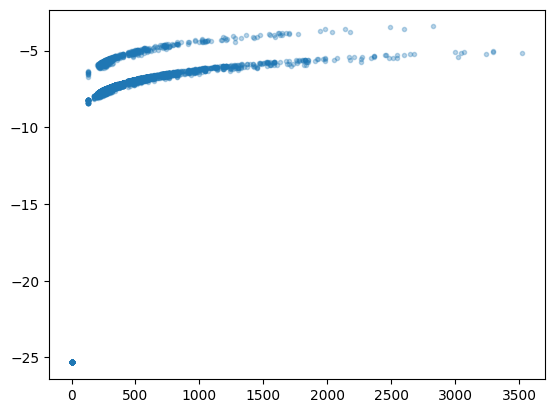

In [131]:
plt.scatter(df_arr_dep_large_time['distance_m'],np.log(df_arr_dep_large_time['speed_m_s']+0.00000000001), marker='.' , alpha=0.3)

In [28]:
df_arr_dep_large_time.head()

,index,id,location,species,time_dt,time_diff,is_new_visit,is_arrival,is_departure,prev_location,distance_m,speed_m_s
45,378016,c695905,1d,bluti,2012-09-09 06:20:07,55980.0,True,True,False,1c,275.870519,0.004928
164,928948,c695905,1d,bluti,2012-09-22 08:23:40,503874.0,True,True,False,1c,275.870519,0.000547
299,1620937,c695905,1c,bluti,2012-09-30 07:04:00,53563.0,True,True,False,1d,275.870519,0.005150
340,1802599,c695905,1d,bluti,2012-10-06 07:13:11,495328.0,True,True,False,1c,275.870519,0.000557
592,3861078,c695905,1c,bluti,2012-11-10 09:30:07,582588.0,True,True,False,1d,275.870519,0.000474


In [18]:
df_fast = df_arr_dep.copy()
df_fast['faster_than_20'] = df_fast['speed_m_s'] > 20
df_fast['keep'] = (df_fast['faster_than_20']==True) | (df_fast['faster_than_20'].shift(1, fill_value=False) | df_fast['faster_than_20'].shift(-1, fill_value=False))
df_fast_check = df_fast[df_fast['keep']].copy()
print(f"Number of rows with speed > 20 m/s or adjacent to such rows: {len(df_fast_check)}")
df_fast_check.head(20)

Number of rows with speed > 20 m/s or adjacent to such rows: 270


,index,id,location,species,time_dt,time_diff,is_new_visit,is_arrival,is_departure,prev_location,distance_m,speed_m_s,faster_than_20,keep
196079,1714583,l171445,2i,marti,2012-01-01 08:57:35,1.0,False,False,True,2i,0.000000,0.000000,False,True
196080,1714658,l171445,3b,marti,2012-01-01 08:57:48,13.0,True,True,False,2i,283.778082,21.829083,True,True
196085,1715895,l171445,3b,marti,2012-01-01 09:00:59,1.0,False,False,True,3b,0.000000,0.000000,False,True
196097,1719421,l171445,2i,marti,2012-01-01 09:09:05,1.0,False,False,True,2i,0.000000,0.000000,False,True
196098,1719429,l171445,3b,marti,2012-01-01 09:09:06,1.0,True,True,True,2i,283.778082,283.778082,True,True
196099,1719440,l171445,2i,marti,2012-01-01 09:09:07,1.0,True,True,True,3b,283.778082,283.778082,True,True
196100,1719441,l171445,3b,marti,2012-01-01 09:09:07,0.0,True,True,True,2i,283.778082,NaN,False,True
196101,1719453,l171445,2i,marti,2012-01-01 09:09:09,2.0,True,True,False,3b,283.778082,141.889041,True,True
196116,1719616,l171445,2i,marti,2012-01-01 09:09:24,1.0,False,False,True,2i,0.000000,0.000000,False,True
196399,2143973,l171445,3b,marti,2012-01-08 10:45:17,1.0,False,False,True,3b,0.000000,0.000000,False,True


In [18]:
fast_gt20_ms = df_arr_dep[
    (df_arr_dep['speed_m_s'].gt(20)) &
    (~df_arr_dep['location'].astype(str).str.strip().str.lower().eq('3b')) &
    (~df_arr_dep['prev_location'].astype(str).str.strip().str.lower().eq('3b'))
]
fast_gt20_ms = df_arr_dep[
    (df_arr_dep['speed_m_s'].gt(20))
]
fast_dep_locations = fast_gt20_ms['prev_location'].dropna().unique()
fast_arr_locations = fast_gt20_ms['location'].unique()
print(f"departure Locations with speeds greater than 20 m/s: {fast_dep_locations},{len(fast_dep_locations)}")
print(f"arrival Locations with speeds greater than 20 m/s: {fast_arr_locations},{len(fast_arr_locations)}")
fast_gt20_ms.head()

departure Locations with speeds greater than 20 m/s: ['2b' '2i' '6i' '2f' '3g' '7h' '5i' '3d' '8f' '2d' '5c' '2e' '3b' '2h'
 '2g' '5d' '5e' '8e' '2c'],19
arrival Locations with speeds greater than 20 m/s: ['2i' '2b' '6h' '8e' '7h' '3g' '5i' '8f' '3d' '2c' '2e' '4b' '4a' '2h'
 '3b' '2d' '2f' '5e' '5d' '5g' '3c'],21


,index,id,location,species,time_dt,time_diff,is_new_visit,is_arrival,is_departure,prev_location,distance_m,speed_m_s
292359,387726,l171445,2i,marti,2012-09-09 06:56:46,18.0,True,True,False,2b,375.532955,20.862942
292361,387788,l171445,2b,marti,2012-09-09 06:57:01,14.0,True,True,False,2i,375.532955,26.823782
971018,84417,l314221,6h,marti,2012-09-02 06:34:20,1.0,True,True,True,6i,220.911747,220.911747
971020,84421,l314221,6h,marti,2012-09-02 06:34:21,1.0,True,True,True,6i,220.911747,220.911747
971022,84425,l314221,6h,marti,2012-09-02 06:34:22,1.0,True,True,True,6i,220.911747,220.911747


In [19]:
max_speed = df_arr_dep.groupby('species')['speed_m_s'].max().sort_values(ascending=False)
print(max_speed_new_loc.head(10))

species
bluti    948.207062
greti    337.501471
marti    283.778082
coati    125.463446
nutha      0.907469
Name: speed_m_s, dtype: float64


In [149]:
# remove locations with speeds greater than 20 m/s
df_arr_dep_cleaned = df_arr_dep[(~df_arr_dep['prev_location'].isin(fast_dep_locations)) |(~df_arr_dep['prev_location'].isin(fast_arr_locations)) |(~df_arr_dep['location'].isin(fast_dep_locations)) | ~df_arr_dep['location'].isin(fast_arr_locations)].copy()
df_arr_dep_cleaned.head()


NameError: name 'fast_dep_locations' is not defined

In [150]:
# remove speeds when the previous record was from the previous day
df_arr_dep_cleaned = df_arr_dep.copy()
df_arr_dep_cleaned['prev_time_dt'] = df_arr_dep_cleaned.groupby('id')['time_dt'].shift(1)
df_arr_dep_cleaned['same_day'] = df_arr_dep_cleaned['time_dt'].dt.date == df_arr_dep_cleaned['prev_time_dt'].dt.date

df_arr_dep_cleaned['speed_m_s'] = np.where(
    df_arr_dep_cleaned['same_day'] | df_arr_dep_cleaned['prev_time_dt'].isna(),
    df_arr_dep_cleaned['speed_m_s'],
    0.0
)
# df_arr_dep_cleaned = df_arr_dep_cleaned[df_arr_dep_cleaned['same_day'] | df_arr_dep_cleaned['prev_time_dt'].isna()].copy()
df_arr_dep_cleaned.head()

,index,id,location,species,time_dt,time_diff,is_new_visit,is_arrival,is_departure,prev_location,distance_m,speed_m_s,prev_time_dt,same_day
0,205341,c695905,1d,bluti,2012-09-08 06:38:14,NaN,True,True,False,NaN,NaN,NaN,NaT,False
40,320611,c695905,1d,bluti,2012-09-08 13:08:33,453.0,False,False,True,1d,0.000000,0.000000,2012-09-08 06:38:14,True
41,341823,c695905,1c,bluti,2012-09-08 14:41:21,5568.0,True,True,False,1d,275.870519,0.049546,2012-09-08 13:08:33,True
44,343089,c695905,1c,bluti,2012-09-08 14:47:07,48.0,False,False,True,1c,0.000000,0.000000,2012-09-08 14:41:21,True
45,378016,c695905,1d,bluti,2012-09-09 06:20:07,55980.0,True,True,False,1c,275.870519,0.000000,2012-09-08 14:47:07,False


In [21]:
species_order = sorted(df_arr_dep['species'].dropna().unique())
cmap = plt.get_cmap('tab10')
species_color = {sp: cmap(i % 10) for i, sp in enumerate(species_order)}

In [ ]:
# df_arr_dep_cleaned = df_arr_dep

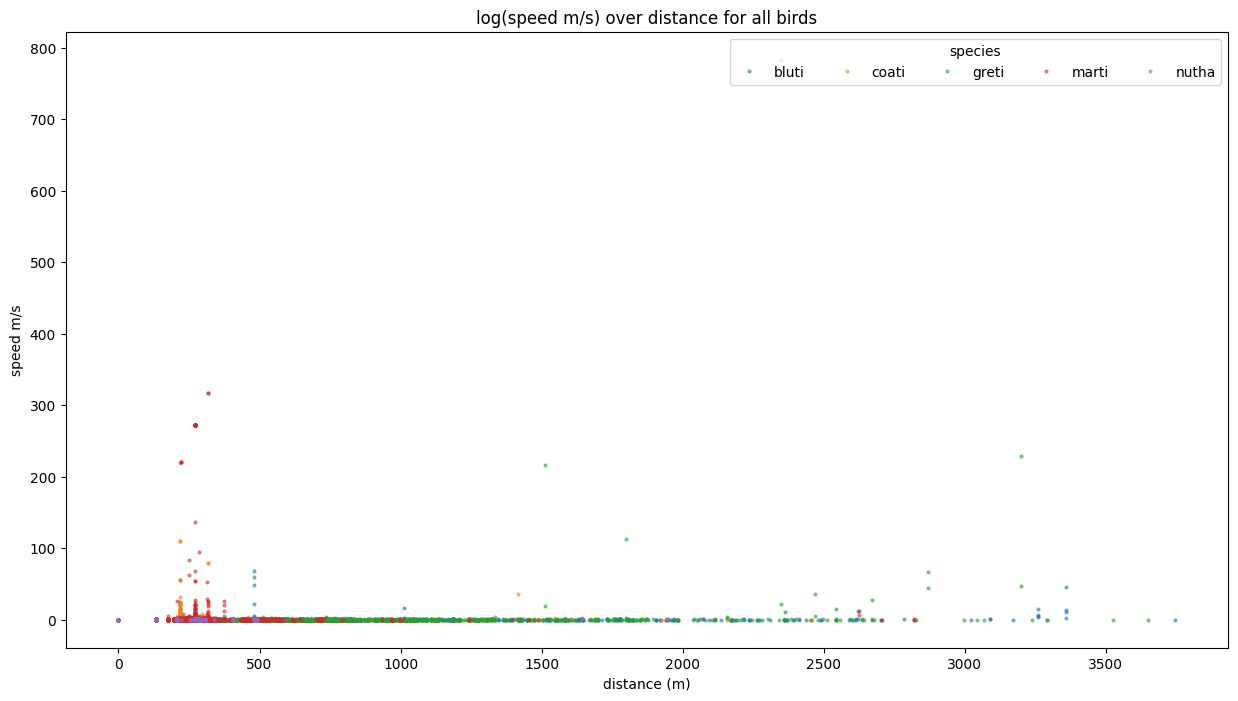

In [151]:
# just plot up to 5m/s
# df_sub = df_arr_dep_cleaned[df_arr_dep_cleaned['speed_m_s'] <= 0.5].copy()
df_sub = df_arr_dep_cleaned.copy()

fig, ax = plt.subplots(figsize=(15, 8))
for sp in species_order:
    # sub = df_arr_dep[df_arr_dep['species'] == sp]
    sub = df_sub[df_arr_dep['species'] == sp]
    if len(sub) == 0:
        continue
    plt.plot(sub['distance_m'], sub['speed_m_s'], '.', ms=4,
             alpha=0.5, color=species_color.get(sp), label=sp)
# fit by eye
x = np.linspace(100,3000,1000)
y = 0.0000028*x-0.000000051
# plt.plot(x, y + 1e-6, 'k-', lw=2, label='linear fit by eye')


# plt.plot(df_visit['distance'], np.log(df_visit['speed_m_s']+0.0000001), '.', alpha=0.3)
plt.xlabel('distance (m)')
plt.ylabel('speed m/s')
plt.title('log(speed m/s) over distance for all birds')
plt.legend(title='species', ncol=len(species_order), loc = 'upper right')

20037


/var/folders/fv/6lp893hd21qcv8d6dcgrwb4w0000gp/T/ipykernel_965/2546740332.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(time_diff_order))


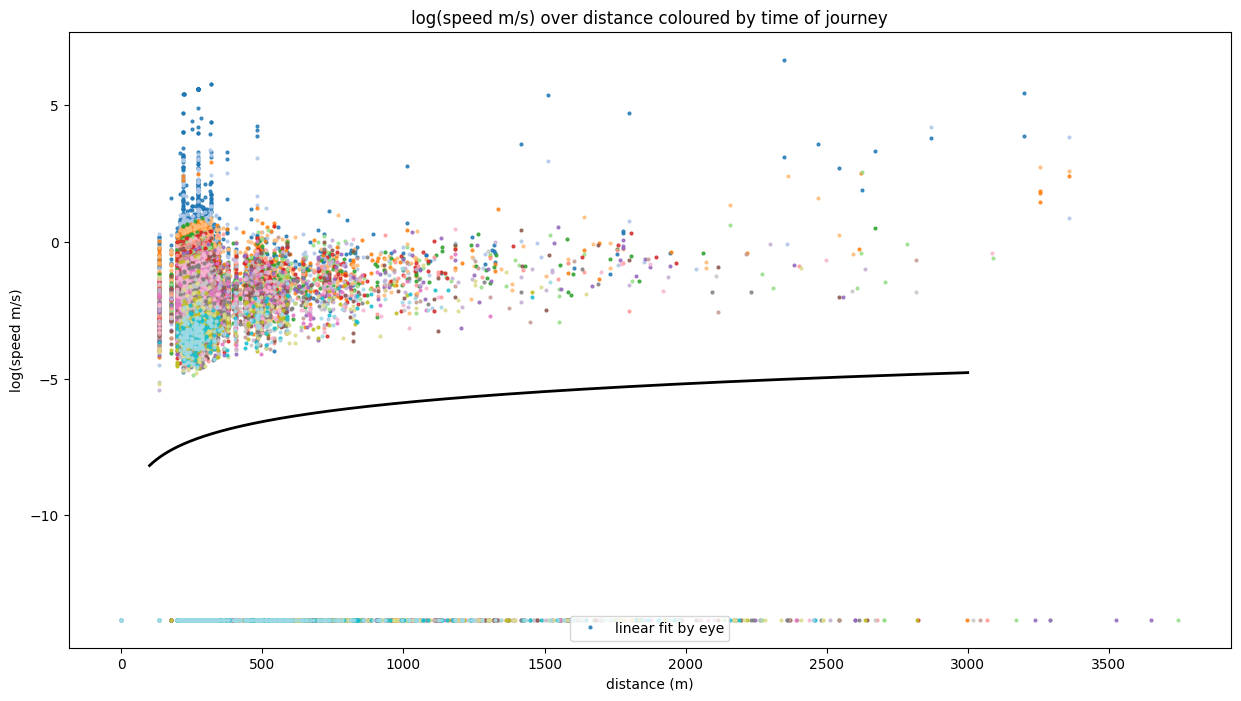

In [152]:
fig, ax = plt.subplots(figsize=(15, 8))

time_diff_order = df_arr_dep_cleaned['time_diff'].dropna().unique()
print(len(time_diff_order))
cmap = cm.get_cmap('tab20', len(time_diff_order))

for i, time_diff in enumerate(time_diff_order):
    sub = df_arr_dep_cleaned[df_arr_dep_cleaned['time_diff'] == time_diff]
    if len(sub) == 0:
        continue
    ax.plot(sub['distance_m'], np.log(sub['speed_m_s'] + 1e-6), '.', ms=4,
            alpha=0.8, color=cmap(i), label=time_diff)

# fit by eye
x = np.linspace(100, 3000, 1000)
y = 0.0000028 * x - 0.000000051
ax.plot(x, np.log(y + 1e-6), 'k-', lw=2, label='linear fit by eye')

plt.xlabel('distance (m)')
plt.ylabel('log(speed m/s)')
plt.title('log(speed m/s) over distance coloured by time of journey')

# show legend only if manageable
if len(time_diff_order) <= 20:
    plt.legend(title='id', ncol=min(len(time_diff_order), 6), loc='lower center')
else:
    plt.legend(['linear fit by eye'], loc='lower center')


17457
26486.264529058117


/var/folders/fv/6lp893hd21qcv8d6dcgrwb4w0000gp/T/ipykernel_965/3727757089.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(None, len(time_diff_order_binned))
/var/folders/fv/6lp893hd21qcv8d6dcgrwb4w0000gp/T/ipykernel_965/3727757089.py:15: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(sub['distance_m'], np.log(sub['speed_m_s'] + 1e-6),cmap='viridis', s=8, alpha=0.6)


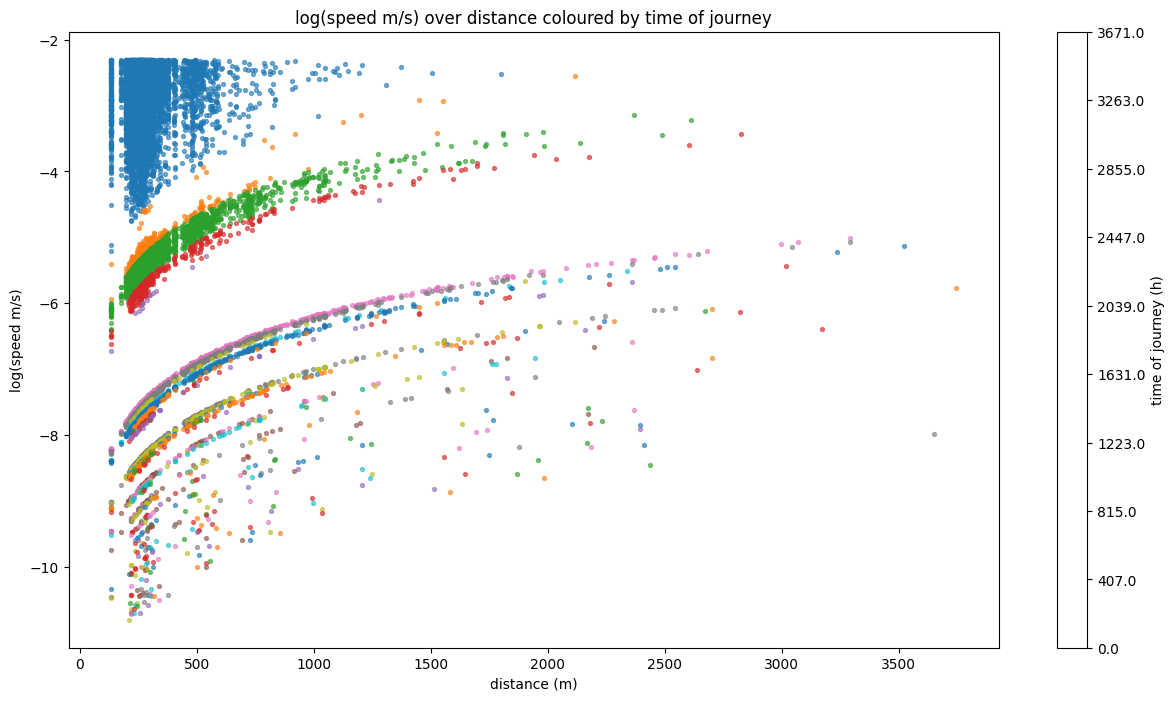

In [34]:
fig, ax = plt.subplots(figsize=(15, 8))

df_arr_dep_cleaned = df_arr_dep_cleaned[(df_arr_dep_cleaned['speed_m_s']>0) & (df_arr_dep_cleaned['speed_m_s']<0.1)].copy()
time_diff_order = df_arr_dep_cleaned['time_diff'].dropna().unique()
print(len(time_diff_order))
time_diff_order_binned = np.linspace(0,time_diff_order.max(),500)
delta = time_diff_order_binned[1]-time_diff_order_binned[0]
print(delta)
cmap = cm.get_cmap(None, len(time_diff_order_binned))

for i, time_diff in enumerate(time_diff_order_binned):
    sub = df_arr_dep_cleaned[(df_arr_dep_cleaned['time_diff'] <= time_diff) & (df_arr_dep_cleaned['time_diff']>=time_diff-delta)]
    if len(sub) == 0:
        continue
    sc = ax.scatter(sub['distance_m'], np.log(sub['speed_m_s'] + 1e-6),cmap='viridis', s=8, alpha=0.6)

# fit by eye
x = np.linspace(100, 3000, 1000)
y = 0.0000028 * x - 0.000000051
# ax.plot(x, np.log(y + 1e-6), 'k-', lw=2, label='linear fit by eye')
tick_vals = np.linspace(0, time_diff_order.max(), 10)
tick_vals //= 3600
cbar = plt.colorbar(sc, ax=ax)
cbar.set_ticks(tick_vals)
cbar.set_ticklabels(tick_vals)
cbar.set_label('time of journey (h)')
plt.xlabel('distance (m)')
plt.ylabel('log(speed m/s)')
plt.title('log(speed m/s) over distance coloured by time of journey')

# show legend only if manageable
if len(time_diff_order_binned) <= 20:
    plt.legend(title='id', ncol=min(len(time_diff_order), 6), loc='lower center')
else:
    pass
    # plt.legend(['linear fit by eye'], loc='lower center')


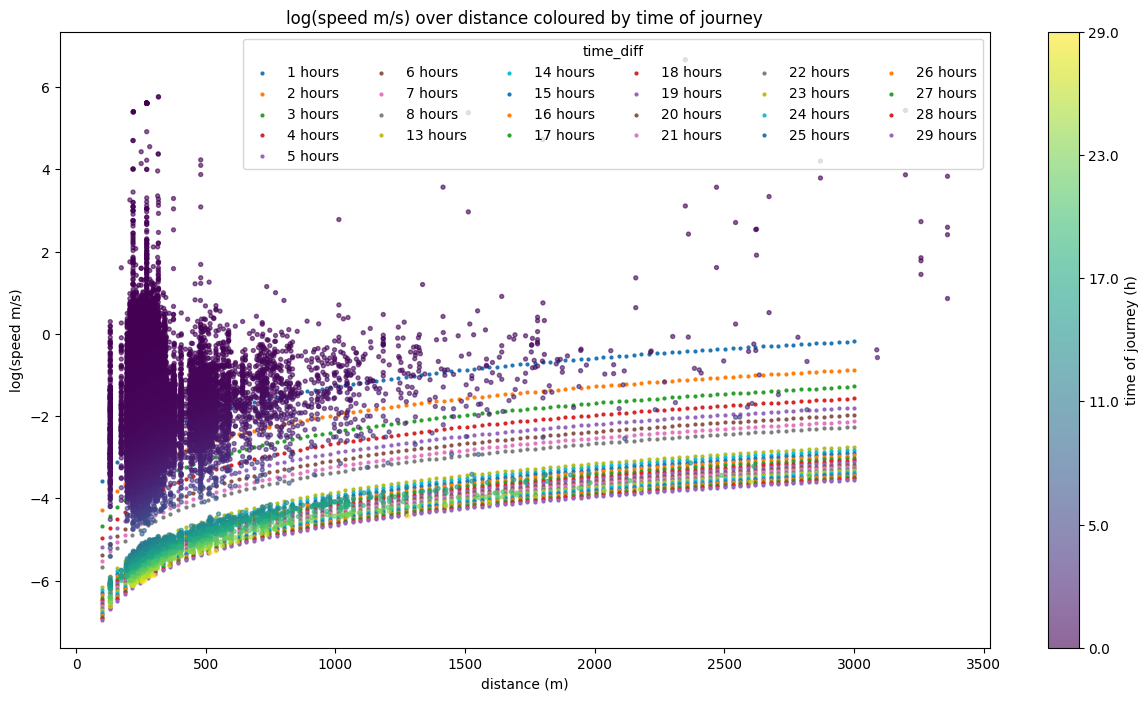

In [148]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 8))

# filter as you had
df = df_arr_dep.copy()
# df = df_arr_dep_cleaned.copy()
# df = df[(df['speed_m_s'] > 0) & (df['speed_m_s'] < 0.1)].copy()
df = df[(df['speed_m_s'] > 0) & (df['time_diff']<30*3600)].copy()

d = np.linspace(100, 3000, 100)
for i in range(1,9):
    t = i*3600   
    y = d/t
    sc = ax.scatter(d,np.log(y), label=f'{i} hours',s = 4 )
for i in range(13,30):
    t = i*3600   
    y = d/t
    sc = ax.scatter(d,np.log(y), label=f'{i} hours',s = 4 )
# for i in range(1,20):
#     t = i*24*3600   
#     y = d/t
#     sc = ax.scatter(d,np.log(y), label=f'{i} days',s = 4 )
# single scatter with color mapped to time_diff (seconds)
sc = ax.scatter(
    df['distance_m'],
    np.log(df['speed_m_s'] + 1e-6),
    c=df['time_diff'],           # <-- numeric values to map
    cmap='viridis',
    s=8,
    alpha=0.6,
    vmin=0,                      # optional: ensure consistent scale
    vmax=df['time_diff'].max()
)

# colorbar: ticks in hours but underlying data are seconds
cbar = plt.colorbar(sc, ax=ax)
# pick tick positions in seconds then label in hours
tick_secs = np.linspace(0, df['time_diff'].max(), 6)
cbar.set_ticks(tick_secs)
cbar.set_ticklabels((tick_secs // 3600))   # show hours, rounded
cbar.set_label('time of journey (h)')
plt.legend(title='time_diff', ncol=6, loc='upper right')
plt.xlabel('distance (m)')
plt.ylabel('log(speed m/s)')
plt.title('log(speed m/s) over distance coloured by time of journey')
plt.show()


/var/folders/fv/6lp893hd21qcv8d6dcgrwb4w0000gp/T/ipykernel_2334/2413040925.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('CMRmap', len(time_diff_binned))


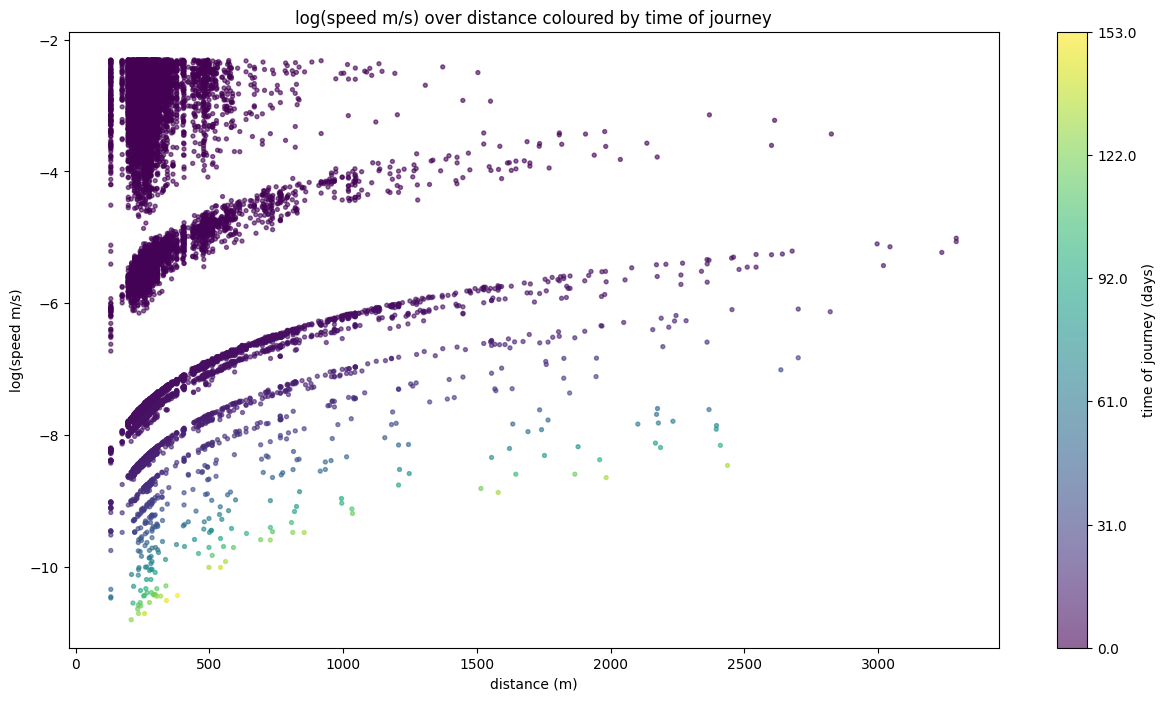

In [47]:
fig, ax = plt.subplots(figsize=(15, 8))

df = df_arr_dep_cleaned.copy()
df = df[(df['speed_m_s'] > 0) & (df['speed_m_s'] < 0.1)].copy()

time_diff_order = df['time_diff'].dropna().unique()
time_diff_binned = np.linspace(0, time_diff_order.max(), 1000)
delta = time_diff_binned[1] - time_diff_binned[0]

# We'll keep a reference mappable by plotting an invisible scatter for the colorbar,
# or reuse the last scatter but ensure every scatter used the same vmin/vmax.
sc = None
vmin = 0
vmax = time_diff_order.max()
cmap = cm.get_cmap('CMRmap', len(time_diff_binned))

for time_diff in time_diff_binned:
    sub = df[(df['time_diff'] <= time_diff) & (df['time_diff'] >= time_diff - delta)]
    if len(sub) == 0:
        continue
    # pass c as the numeric scalar 'time_diff' for that bin
    sc = ax.scatter(
        sub['distance_m'],
        np.log(sub['speed_m_s'] + 1e-6),
        c=np.full(len(sub), time_diff),
        s=8,
        alpha=0.6,
        vmin=vmin,
        vmax=vmax
    )

# create colorbar from the last scatter (sc is a ScalarMappable-like PathCollection)
cbar = plt.colorbar(sc, ax=ax)
tick_secs = np.linspace(0, vmax, 6)
cbar.set_ticks(tick_secs)
cbar.set_ticklabels((tick_secs / (24*3600)).round())
cbar.set_label('time of journey (days)')

plt.xlabel('distance (m)')
plt.ylabel('log(speed m/s)')
plt.title('log(speed m/s) over distance coloured by time of journey')
plt.show()


/var/folders/fv/6lp893hd21qcv8d6dcgrwb4w0000gp/T/ipykernel_4921/21067229.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(loc_order))


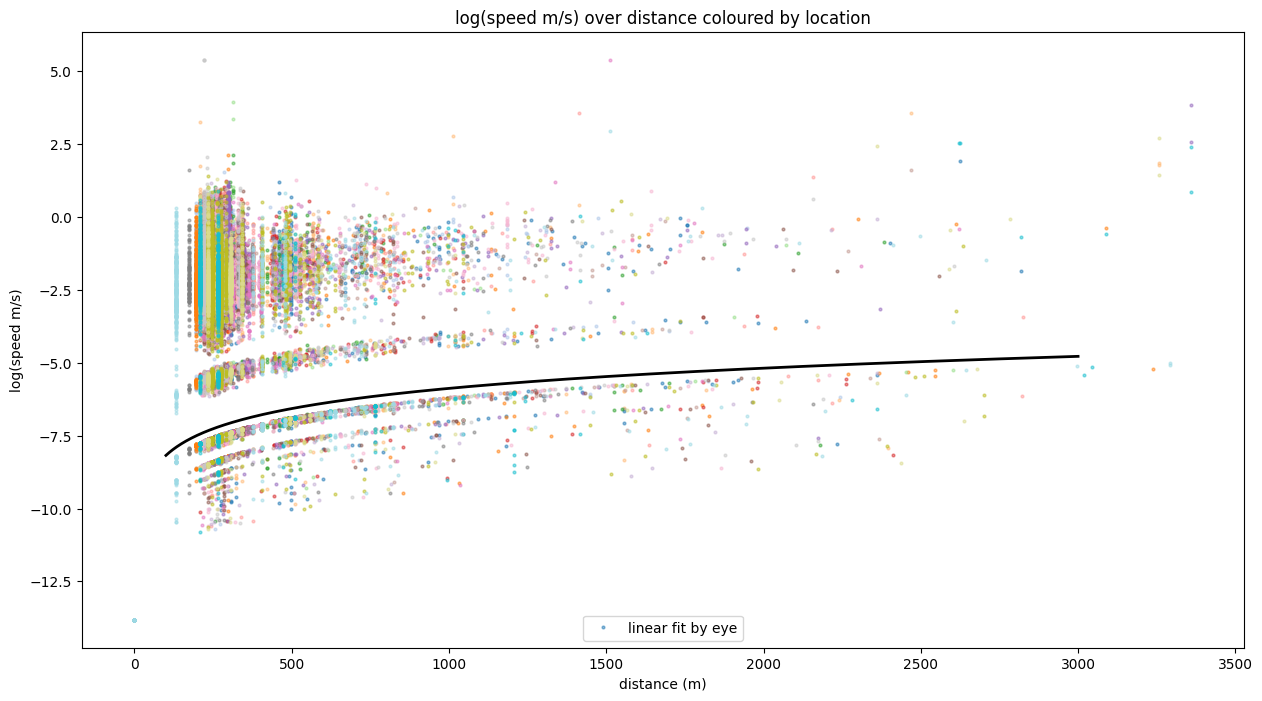

In [ ]:
fig, ax = plt.subplots(figsize=(15, 8))

loc_order = sorted(df_arr_dep_cleaned['location'].dropna().unique())
cmap = cm.get_cmap('tab20', len(loc_order))

for i, loc in enumerate(loc_order):
    sub = df_arr_dep_cleaned[df_arr_dep_cleaned['location'] == loc]
    if len(sub) == 0:
        continue
    ax.plot(sub['distance_m'], np.log(sub['speed_m_s'] + 1e-6), '.', ms=4,
            alpha=0.5, color=cmap(i), label=str(loc))

# fit by eye
x = np.linspace(100, 3000, 1000)
y = 0.0000028 * x - 0.000000051
ax.plot(x, np.log(y + 1e-6), 'k-', lw=2, label='linear fit by eye')

plt.xlabel('distance (m)')
plt.ylabel('log(speed m/s)')
plt.title('log(speed m/s) over distance coloured by location')

# show legend only if manageable
if len(loc_order) <= 20:
    plt.legend(title='location', ncol=min(len(loc_order), 6), loc='lower center')
else:
    plt.legend(['linear fit by eye'], loc='lower center')


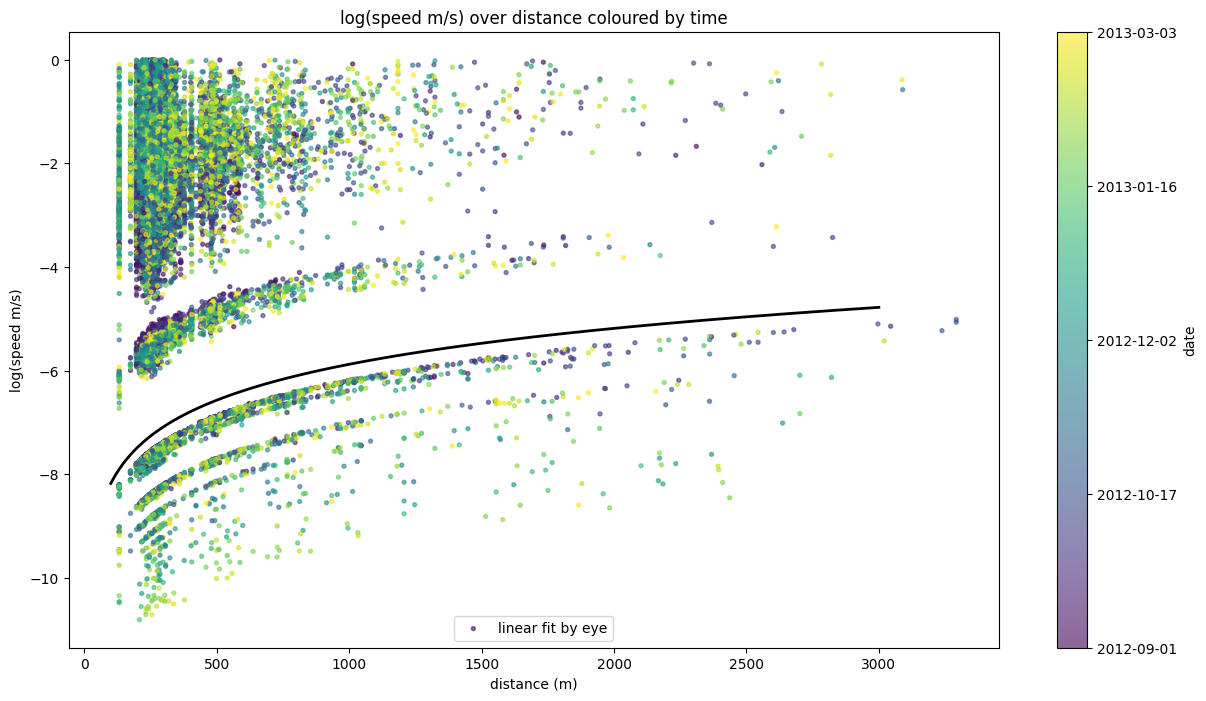

In [ ]:
fig, ax = plt.subplots(figsize=(15, 8))

# data
sub = df_arr_dep_cleaned.dropna(subset=['distance_m', 'speed_m_s', 'time_dt']).copy()
xdata = sub['distance_m'].values
ydata = np.log(sub['speed_m_s'].values + 1e-6)
tsecs = (sub['time_dt'].astype('int64') // 10**9).values  # seconds since epoch for colouring

# scatter coloured by time
sc = ax.scatter(xdata, ydata, c=tsecs, cmap='viridis', s=8, alpha=0.6)

# fit by eye
x = np.linspace(100, 3000, 1000)
y = 0.0000028 * x - 0.000000051
ax.plot(x, np.log(y + 1e-6), 'k-', lw=2, label='linear fit by eye')

plt.xlabel('distance (m)')
plt.ylabel('log(speed m/s)')
plt.title('log(speed m/s) over distance coloured by time')

# colorbar with human-readable ticks
cbar = plt.colorbar(sc, ax=ax)
tick_vals = np.linspace(tsecs.min(), tsecs.max(), 5)
cbar.set_ticks(tick_vals)
cbar.set_ticklabels(pd.to_datetime(tick_vals, unit='s').strftime('%Y-%m-%d'))
cbar.set_label('date')

plt.legend(['linear fit by eye'], loc='lower center')
